In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Locate the repository whether the notebook is run from the project root,
# the notebooks folder, or the parent directory.
cwd = Path.cwd()
candidates = [
    cwd,
    cwd.parent,
    cwd / "care-manager-care-gap-prioritization"
]

for candidate in candidates:
    if (candidate / "data" / "care_manager_daily_workload.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate data/care_manager_daily_workload.csv")

DATA_PATH = PROJECT_ROOT / "data" / "care_manager_daily_workload.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Project root: /mnt/data/care-manager-care-gap-prioritization
Dataset: /mnt/data/care-manager-care-gap-prioritization/data/care_manager_daily_workload.csv


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Unique patients: {df['patient_id'].nunique():,}")

df.head(5)

Rows: 2,500
Columns: 73
Unique patients: 2,500


,snapshot_date,patient_id,care_manager_id,source_system,region,insurance_product,age,sex,preferred_language,preferred_contact_channel,diabetes_flag,hypertension_flag,chf_flag,copd_flag,ckd_flag,depression_flag,cad_flag,active_cancer_flag,frailty_flag,chronic_condition_count,hcc_risk_score,risk_tier,ed_visits_90d,observation_stays_90d,inpatient_admits_12m,recent_discharge_30d_flag,days_since_discharge,a1c_value,systolic_bp,a1c_overdue_gap,retinal_exam_gap,nephropathy_screen_gap,bp_control_gap,med_reconciliation_gap,post_discharge_followup_gap,preventive_screening_gap,vaccination_gap,behavioral_health_followup_gap,statin_therapy_gap,medication_count,medication_pdc,medication_adherence_gap,refill_due_7d_flag,food_insecurity,transportation_barrier,housing_instability,social_isolation,financial_strain,sdoh_positive_count,last_contact_date,days_since_last_contact,unanswered_outreach_30d,scheduled_call_today_flag,symptom_change_reported_flag,community_resource_referral_open_flag,home_health_need_flag,transportation_service_needed_flag,specialist_appointment_pending_flag,provider_message_pending_flag,specialist_count,care_plan_status,care_plan_days_since_update,documentation_note_backlog,billing_activity_code_pending_flag,health_literacy,education_need,open_care_gap_count,task_type,task_age_days,task_due_date,sla_overdue_flag,legacy_priority,unplanned_acute_event_30d
0,2026-10-01,PT-000001,CM-004,Claims,Northeast,Medicare Advantage,73,Male,English,SMS,1,1,0,1,1,0,0,0,0,4,1.80,High,0,0,1,0,NaN,8.6,165,0,0,1,1,0,0,0,0,0,0,12,0.65,1,0,No,Unknown,No,Yes,Yes,2,2026-09-10,21,0,1,0,0,0,0,1,0,3,Not Started,NaN,0,0,Adequate,Diet/Lifestyle,3,Medication Review,13,2026-10-06,0,P2,0
1,2026-10-01,PT-000002,CM-016,EHR,Northeast,Medicare Advantage,81,Male,English,Phone,1,0,0,0,1,0,0,0,1,2,1.41,Medium,0,0,0,0,NaN,5.2,127,0,1,0,0,0,0,0,0,0,0,1,0.95,0,0,No,No,No,No,No,0,NaN,22,0,0,0,0,0,0,1,0,0,Not Started,NaN,0,0,Adequate,COPD,1,Care Gap Closure,2,2026-10-06,0,P2,0
2,2026-10-01,PT-000003,CM-018,Claims,Southwest,Medicaid Managed Care,45,Female,English,Phone,0,1,1,0,0,1,0,0,0,3,1.73,Medium,0,0,0,0,NaN,NaN,116,0,0,0,0,0,0,0,0,0,0,11,0.86,0,0,No,Yes,Unknown,No,Yes,2,2026-08-18,44,0,1,0,0,0,0,0,1,3,Current,32.0,0,0,Unknown,Medication,0,Provider Follow-up,2,2026-10-04,0,P3,0
3,2026-10-01,PT-000004,CM-018,CareMgmt,Northeast,Dual Eligible,68,Female,English,Phone,1,0,0,0,1,0,0,0,0,2,1.08,Medium,0,0,2,0,NaN,NaN,135,1,0,0,0,0,0,0,0,0,1,5,0.69,1,0,Unknown,No,Yes,No,Unknown,1,2026-09-10,21,4,0,0,0,0,0,0,0,3,Overdue,177.0,0,0,Adequate,Medication,3,Care Gap Closure,0,2026-10-01,0,P4,0
4,2026-10-01,PT-000005,CM-003,Claims,Northeast,Dual Eligible,75,Female,English,Phone,0,0,1,0,0,1,1,0,0,3,0.95,High,0,0,3,0,NaN,NaN,128,0,0,0,0,0,0,0,0,0,0,8,0.49,1,1,Yes,Yes,Yes,No,No,3,2026-08-06,56,0,1,0,0,0,0,1,0,4,Current,37.0,0,0,Limited,Appointment Preparation,1,Patient Outreach,2,2026-10-01,0,P4,0


In [3]:
duplicate_patients = df["patient_id"].duplicated().sum()

missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_nonzero = missing_summary[missing_summary["missing_count"] > 0]

print(f"Duplicate patient IDs: {duplicate_patients}")
print(f"Columns containing missing values: {len(missing_nonzero)}")

missing_nonzero

Duplicate patient IDs: 0
Columns containing missing values: 5


,missing_count,missing_pct
days_since_discharge,2331,93.24
a1c_value,1875,75.00
education_need,683,27.32
care_plan_days_since_update,185,7.40
last_contact_date,55,2.20


In [4]:
risk_summary = (
    df.groupby("risk_tier", observed=True)
      .agg(
          patients=("patient_id", "count"),
          avg_open_care_gaps=("open_care_gap_count", "mean"),
          avg_ed_visits_90d=("ed_visits_90d", "mean"),
          recent_discharge_rate=("recent_discharge_30d_flag", "mean"),
          acute_event_rate=("unplanned_acute_event_30d", "mean"),
          sla_overdue_rate=("sla_overdue_flag", "mean")
      )
      .reset_index()
)

risk_order = pd.CategoricalDtype(
    ["Low", "Medium", "High"],
    ordered=True
)

risk_summary["risk_tier"] = risk_summary["risk_tier"].astype(risk_order)
risk_summary = risk_summary.sort_values("risk_tier")

for col in ["recent_discharge_rate", "acute_event_rate", "sla_overdue_rate"]:
    risk_summary[col] = (risk_summary[col] * 100).round(1)

risk_summary["avg_open_care_gaps"] = risk_summary["avg_open_care_gaps"].round(2)
risk_summary["avg_ed_visits_90d"] = risk_summary["avg_ed_visits_90d"].round(2)

risk_summary

,risk_tier,patients,avg_open_care_gaps,avg_ed_visits_90d,recent_discharge_rate,acute_event_rate,sla_overdue_rate
1,Low,1486,1.13,0.14,1.6,3.0,39.9
2,Medium,778,1.98,0.49,11.3,5.4,38.2
0,High,236,2.78,1.34,24.2,11.4,40.7


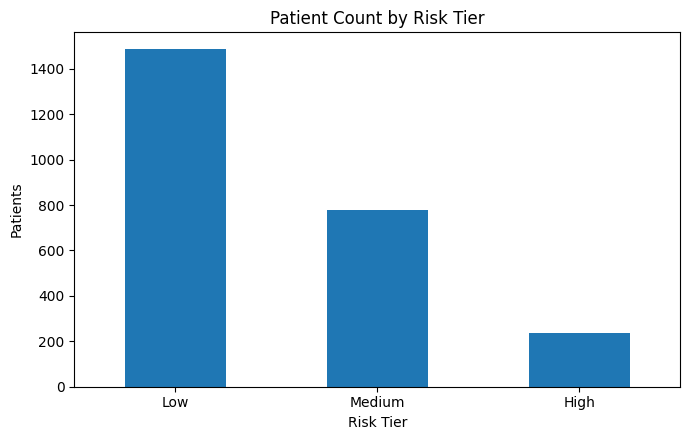

In [5]:
risk_counts = (
    df["risk_tier"]
      .value_counts()
      .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(7, 4.5))
risk_counts.plot(kind="bar")
plt.title("Patient Count by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
care_gap_columns = [
    "a1c_overdue_gap",
    "retinal_exam_gap",
    "nephropathy_screen_gap",
    "bp_control_gap",
    "med_reconciliation_gap",
    "post_discharge_followup_gap",
    "preventive_screening_gap",
    "vaccination_gap",
    "behavioral_health_followup_gap",
    "statin_therapy_gap",
    "medication_adherence_gap"
]

gap_prevalence = (
    df[care_gap_columns]
      .mean()
      .sort_values(ascending=False)
      .mul(100)
      .round(1)
      .rename("prevalence_pct")
      .reset_index()
      .rename(columns={"index": "care_gap"})
)

gap_prevalence

,care_gap,prevalence_pct
0,medication_adherence_gap,36.1
1,bp_control_gap,22.5
2,preventive_screening_gap,19.8
3,vaccination_gap,16.7
4,med_reconciliation_gap,11.8
5,statin_therapy_gap,11.6
6,retinal_exam_gap,8.8
7,behavioral_health_followup_gap,7.7
8,a1c_overdue_gap,7.4
9,post_discharge_followup_gap,6.6


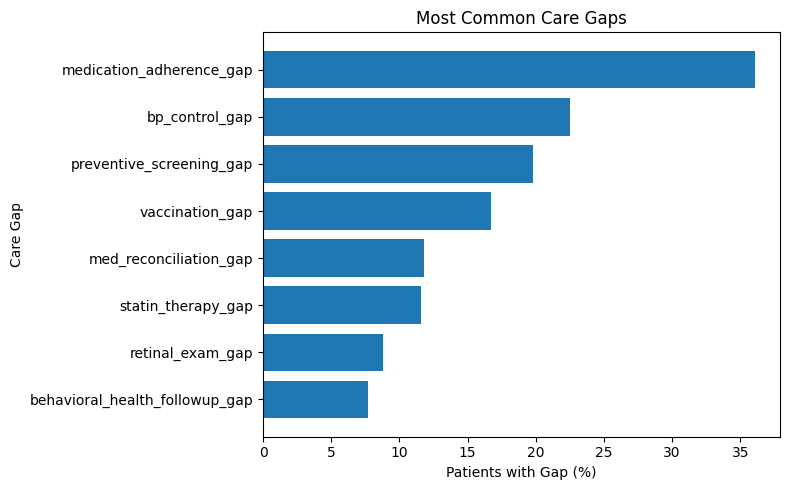

In [7]:
gap_plot = gap_prevalence.head(8).sort_values("prevalence_pct")

plt.figure(figsize=(8, 5))
plt.barh(gap_plot["care_gap"], gap_plot["prevalence_pct"])
plt.title("Most Common Care Gaps")
plt.xlabel("Patients with Gap (%)")
plt.ylabel("Care Gap")
plt.tight_layout()
plt.show()

In [8]:
risk_points = (
    df["risk_tier"]
      .map({"Low": 0, "Medium": 12, "High": 24})
      .astype(float)
)

df["analytic_priority_score"] = (
    risk_points
    + 16 * df["recent_discharge_30d_flag"]
    + 4 * df["ed_visits_90d"].clip(upper=3)
    + 3 * df["inpatient_admits_12m"].clip(upper=3)
    + 4 * df["open_care_gap_count"].clip(upper=5)
    + 8 * df["medication_adherence_gap"]
    + 3 * df["sdoh_positive_count"].clip(upper=4)
    + 10 * df["symptom_change_reported_flag"]
    + 2 * df["unanswered_outreach_30d"].clip(upper=3)
    + 8 * df["sla_overdue_flag"]
    + 6 * df["frailty_flag"]
    + 4 * df["provider_message_pending_flag"]
    + 4 * df["home_health_need_flag"]
    + 4 * df["care_plan_status"].isin(["Overdue", "Not Started"]).astype(int)
).clip(upper=100).round().astype(int)

df["analytic_priority_band"] = pd.cut(
    df["analytic_priority_score"],
    bins=[-1, 29, 49, 69, 100],
    labels=["Routine", "Elevated", "High", "Critical"]
)

df["analytic_rank"] = (
    df["analytic_priority_score"]
      .rank(method="first", ascending=False)
      .astype(int)
)

priority_band_summary = (
    df.groupby("analytic_priority_band", observed=True)
      .agg(
          patients=("patient_id", "count"),
          avg_score=("analytic_priority_score", "mean"),
          avg_open_gaps=("open_care_gap_count", "mean"),
          acute_event_rate=("unplanned_acute_event_30d", "mean")
      )
      .reset_index()
)

priority_band_summary["avg_score"] = priority_band_summary["avg_score"].round(1)
priority_band_summary["avg_open_gaps"] = priority_band_summary["avg_open_gaps"].round(2)
priority_band_summary["acute_event_rate"] = (
    priority_band_summary["acute_event_rate"] * 100
).round(1)

priority_band_summary

,analytic_priority_band,patients,avg_score,avg_open_gaps,acute_event_rate
0,Routine,1555,15.4,1.04,3.0
1,Elevated,666,38.5,2.09,5.7
2,High,222,57.5,2.95,7.7
3,Critical,57,80.5,3.70,19.3


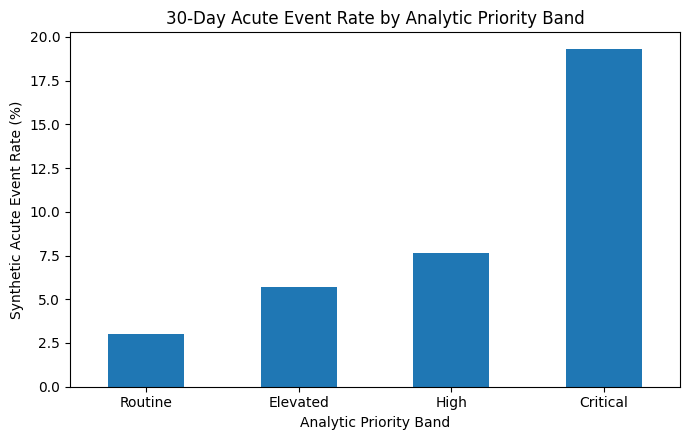

In [9]:
event_by_band = (
    df.groupby("analytic_priority_band", observed=True)
      ["unplanned_acute_event_30d"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(7, 4.5))
event_by_band.plot(kind="bar")
plt.title("30-Day Acute Event Rate by Analytic Priority Band")
plt.xlabel("Analytic Priority Band")
plt.ylabel("Synthetic Acute Event Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
worklist_columns = [
    "analytic_rank",
    "patient_id",
    "care_manager_id",
    "analytic_priority_score",
    "analytic_priority_band",
    "legacy_priority",
    "risk_tier",
    "task_type",
    "open_care_gap_count",
    "recent_discharge_30d_flag",
    "ed_visits_90d",
    "inpatient_admits_12m",
    "medication_adherence_gap",
    "sdoh_positive_count",
    "symptom_change_reported_flag",
    "unanswered_outreach_30d",
    "sla_overdue_flag",
    "provider_message_pending_flag"
]

top_20_worklist = (
    df.sort_values(
        ["analytic_priority_score", "open_care_gap_count", "ed_visits_90d"],
        ascending=False
    )[worklist_columns]
    .head(20)
)

top_20_worklist

,analytic_rank,patient_id,care_manager_id,analytic_priority_score,analytic_priority_band,legacy_priority,risk_tier,task_type,open_care_gap_count,recent_discharge_30d_flag,ed_visits_90d,inpatient_admits_12m,medication_adherence_gap,sdoh_positive_count,symptom_change_reported_flag,unanswered_outreach_30d,sla_overdue_flag,provider_message_pending_flag
1384,1,PT-001385,CM-012,100,Critical,P4,High,Patient Education,4,1,2,1,1,2,1,0,0,1
1116,2,PT-001117,CM-006,97,Critical,P2,High,Post-Discharge Follow-up,6,1,0,1,1,0,1,3,0,0
1547,4,PT-001548,CM-016,96,Critical,P3,High,Care Gap Closure,5,1,1,4,0,1,0,3,1,0
440,3,PT-000441,CM-010,96,Critical,P2,High,Social Resource Referral,2,1,6,0,1,2,1,0,1,0
1938,5,PT-001939,CM-014,95,Critical,P3,High,Social Resource Referral,4,1,2,0,1,3,0,0,0,1
42,6,PT-000043,CM-014,94,Critical,P3,High,Care Gap Closure,4,1,6,0,1,2,0,2,1,0
2121,8,PT-002122,CM-016,92,Critical,P1,High,Post-Discharge Follow-up,5,1,1,1,1,1,0,1,1,0
1231,7,PT-001232,CM-002,92,Critical,P2,High,Patient Outreach,4,1,2,0,0,2,0,4,1,0
1161,9,PT-001162,CM-011,91,Critical,P3,High,Social Resource Referral,3,1,6,0,1,1,0,1,0,1
1206,10,PT-001207,CM-001,91,Critical,P3,High,Care Gap Closure,3,1,4,5,0,0,0,1,1,0


In [11]:
top_patient = top_20_worklist.iloc[0]

print("Highest-priority patient")
print("------------------------")
print(f"Patient ID: {top_patient['patient_id']}")
print(f"Analytic score: {top_patient['analytic_priority_score']}")
print(f"Priority band: {top_patient['analytic_priority_band']}")
print(f"Legacy priority: {top_patient['legacy_priority']}")
print(f"Risk tier: {top_patient['risk_tier']}")
print(f"Open care gaps: {top_patient['open_care_gap_count']}")
print(f"Recent discharge: {bool(top_patient['recent_discharge_30d_flag'])}")
print(f"ED visits (90d): {top_patient['ed_visits_90d']}")
print(f"Medication adherence gap: {bool(top_patient['medication_adherence_gap'])}")
print(f"SDOH positive domains: {top_patient['sdoh_positive_count']}")
print(f"Symptom change reported: {bool(top_patient['symptom_change_reported_flag'])}")
print(f"Overdue work item: {bool(top_patient['sla_overdue_flag'])}")

Highest-priority patient
------------------------
Patient ID: PT-001385
Analytic score: 100
Priority band: Critical
Legacy priority: P4
Risk tier: High
Open care gaps: 4
Recent discharge: True
ED visits (90d): 2
Medication adherence gap: True
SDOH positive domains: 2
Symptom change reported: True
Overdue work item: False


In [12]:
legacy_summary = (
    df.groupby("legacy_priority", observed=True)
      .agg(
          patients=("patient_id", "count"),
          avg_analytic_score=("analytic_priority_score", "mean"),
          high_risk_rate=("risk_tier", lambda s: (s == "High").mean()),
          acute_event_rate=("unplanned_acute_event_30d", "mean"),
          avg_open_gaps=("open_care_gap_count", "mean")
      )
      .reindex(["P1", "P2", "P3", "P4"])
      .reset_index()
)

legacy_summary["avg_analytic_score"] = legacy_summary["avg_analytic_score"].round(1)
legacy_summary["high_risk_rate"] = (legacy_summary["high_risk_rate"] * 100).round(1)
legacy_summary["acute_event_rate"] = (legacy_summary["acute_event_rate"] * 100).round(1)
legacy_summary["avg_open_gaps"] = legacy_summary["avg_open_gaps"].round(2)

legacy_summary

,legacy_priority,patients,avg_analytic_score,high_risk_rate,acute_event_rate,avg_open_gaps
0,P1,287,29.0,14.3,6.3,1.58
1,P2,667,26.8,8.8,4.3,1.56
2,P3,916,26.7,8.8,5.1,1.55
3,P4,630,25.8,8.7,3.0,1.51


In [13]:
total_events = df["unplanned_acute_event_30d"].sum()

top_10_cutoff = df["analytic_priority_score"].quantile(0.90)
analytic_top_decile = df[df["analytic_priority_score"] >= top_10_cutoff]

analytic_capture = (
    analytic_top_decile["unplanned_acute_event_30d"].sum() / total_events
)

legacy_p1 = df[df["legacy_priority"] == "P1"]
legacy_capture = (
    legacy_p1["unplanned_acute_event_30d"].sum() / total_events
)

capture_comparison = pd.DataFrame({
    "method": ["Analytic top ~10%", "Legacy P1"],
    "patients": [len(analytic_top_decile), len(legacy_p1)],
    "acute_event_capture_pct": [
        analytic_capture * 100,
        legacy_capture * 100
    ],
    "within_group_event_rate_pct": [
        analytic_top_decile["unplanned_acute_event_30d"].mean() * 100,
        legacy_p1["unplanned_acute_event_30d"].mean() * 100
    ]
})

capture_comparison.round(1)

,method,patients,acute_event_capture_pct,within_group_event_rate_pct
0,Analytic top ~10%,262,23.9,10.3
1,Legacy P1,287,15.9,6.3


In [14]:
target = "unplanned_acute_event_30d"

numeric_features = [
    "age",
    "diabetes_flag",
    "chf_flag",
    "copd_flag",
    "ckd_flag",
    "frailty_flag",
    "chronic_condition_count",
    "ed_visits_90d",
    "observation_stays_90d",
    "inpatient_admits_12m",
    "recent_discharge_30d_flag",
    "systolic_bp",
    "open_care_gap_count",
    "medication_count",
    "medication_pdc",
    "medication_adherence_gap",
    "sdoh_positive_count",
    "days_since_last_contact",
    "unanswered_outreach_30d",
    "symptom_change_reported_flag",
    "community_resource_referral_open_flag",
    "home_health_need_flag",
    "provider_message_pending_flag",
    "specialist_count",
    "task_age_days",
    "sla_overdue_flag"
]

categorical_features = [
    "insurance_product",
    "care_plan_status",
    "task_type",
    "health_literacy",
    "preferred_contact_channel"
]

X = df[numeric_features + categorical_features].copy()
y = df[target].astype(int)

print("Target distribution:")
target_distribution = (
    y.value_counts()
     .sort_index()
     .rename(index={0: "No acute event", 1: "Acute event"})
     .to_frame("patients")
)

target_distribution["percent"] = (
    target_distribution["patients"] / len(y) * 100
).round(1)

target_distribution

Target distribution:


,patients,percent
unplanned_acute_event_30d,,
No acute event,2387,95.5
Acute event,113,4.5


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 1,875
Test rows: 625


In [16]:
metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "value": [
        accuracy_score(y_test, predictions),
        precision_score(y_test, predictions, zero_division=0),
        recall_score(y_test, predictions, zero_division=0),
        f1_score(y_test, predictions, zero_division=0),
        roc_auc_score(y_test, probabilities)
    ]
})

metrics["value"] = metrics["value"].round(3)
metrics

,metric,value
0,Accuracy,0.651
1,Precision,0.072
2,Recall,0.571
3,F1,0.128
4,ROC-AUC,0.627


In [17]:
cm = confusion_matrix(y_test, predictions)

confusion_df = pd.DataFrame(
    cm,
    index=["Actual: No Event", "Actual: Event"],
    columns=["Predicted: No Event", "Predicted: Event"]
)

confusion_df

,Predicted: No Event,Predicted: Event
Actual: No Event,391,206
Actual: Event,12,16


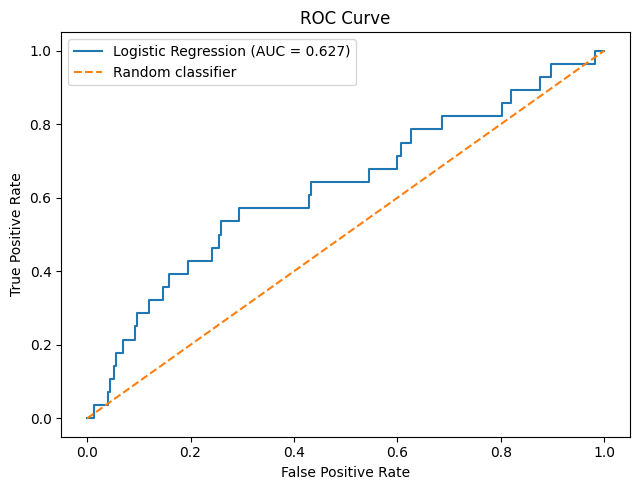

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
auc_value = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(6.5, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
feature_names = (
    model.named_steps["preprocess"]
         .get_feature_names_out()
)

coefficients = (
    model.named_steps["model"]
         .coef_[0]
)

driver_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

driver_table["absolute_coefficient"] = driver_table["coefficient"].abs()

top_drivers = (
    driver_table
      .sort_values("absolute_coefficient", ascending=False)
      .head(15)
      .drop(columns="absolute_coefficient")
)

top_drivers["coefficient"] = top_drivers["coefficient"].round(3)
top_drivers["odds_ratio"] = top_drivers["odds_ratio"].round(3)

top_drivers

,feature,coefficient,odds_ratio
28,categorical__insurance_product_Medicaid Manage...,0.632,1.881
36,categorical__task_type_Medication Review,0.521,1.683
26,categorical__insurance_product_Commercial Comp...,-0.495,0.610
6,numeric__chronic_condition_count,-0.456,0.634
49,categorical__preferred_contact_channel_SMS,-0.432,0.649
38,categorical__task_type_Patient Outreach,0.386,1.471
27,categorical__insurance_product_Dual Eligible,-0.383,0.682
45,categorical__health_literacy_Unknown,0.377,1.458
0,numeric__age,0.363,1.438
35,categorical__task_type_Care Plan Update,-0.353,0.702


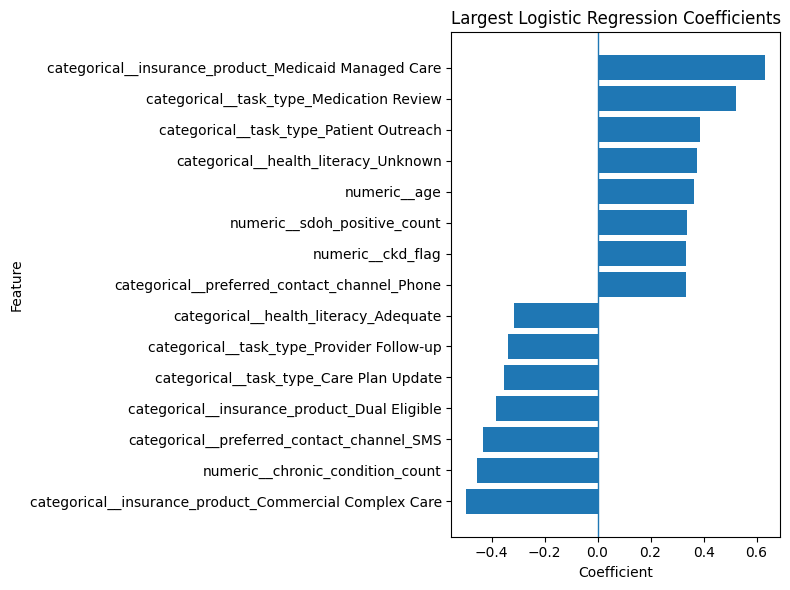

In [20]:
driver_plot = (
    top_drivers
      .sort_values("coefficient")
)

plt.figure(figsize=(8, 6))
plt.barh(driver_plot["feature"], driver_plot["coefficient"])
plt.axvline(0, linewidth=1)
plt.title("Largest Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [21]:
scored_worklist_path = OUTPUT_DIR / "care_manager_scored_worklist.csv"
top_20_path = OUTPUT_DIR / "top_20_priority_patients.csv"
metrics_path = OUTPUT_DIR / "model_metrics.csv"

df.sort_values("analytic_rank").to_csv(
    scored_worklist_path,
    index=False
)

top_20_worklist.to_csv(
    top_20_path,
    index=False
)

metrics.to_csv(
    metrics_path,
    index=False
)

print("Created:")
print(f"- {scored_worklist_path}")
print(f"- {top_20_path}")
print(f"- {metrics_path}")

Created:
- /mnt/data/care-manager-care-gap-prioritization/outputs/care_manager_scored_worklist.csv
- /mnt/data/care-manager-care-gap-prioritization/outputs/top_20_priority_patients.csv
- /mnt/data/care-manager-care-gap-prioritization/outputs/model_metrics.csv
